<a href="https://colab.research.google.com/github/Katrina0104/StrawberryDetection/blob/main/Strawberry_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

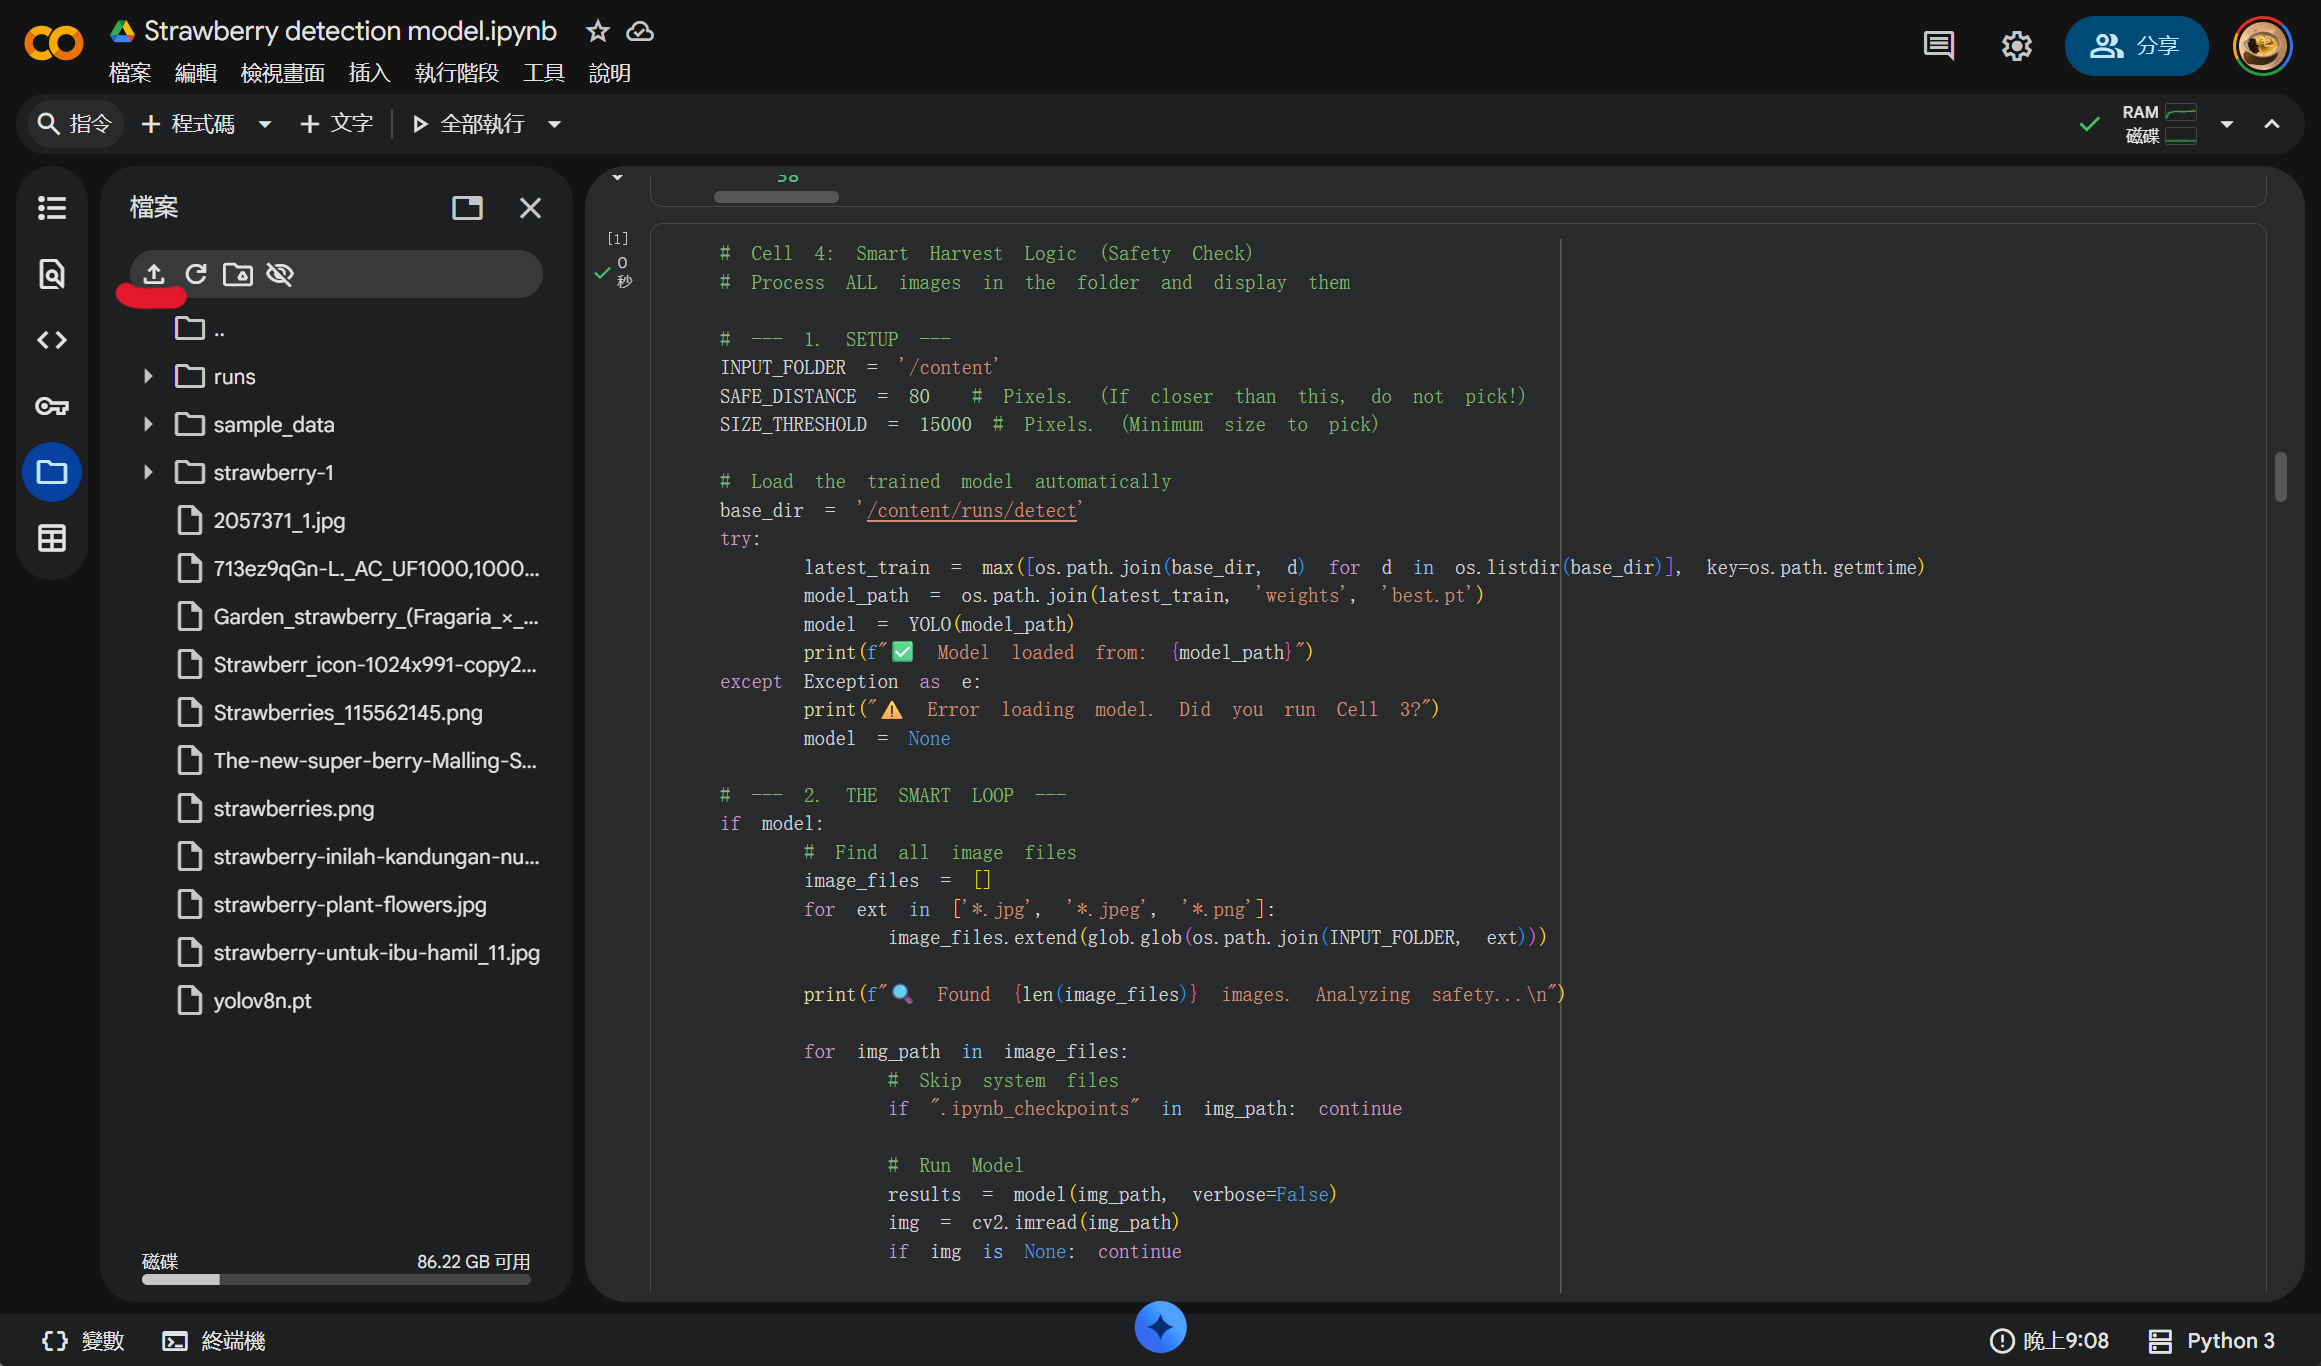

After compile the first 3 cells, upload the images from dataset by press the button marked in red

In [ ]:
# Cell 1: Install Libraries
!pip install ultralytics roboflow

import os
import glob
import math
import cv2
import shutil
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import display, Image

print("✅ Installation Complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 119.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with

In [ ]:
# Cell 2: Download the Data
# Using your specific key and project
rf = Roboflow(api_key="Wdd8CNY08mMSYBb6sIvd")
project = rf.workspace("psychoopomp").project("strawberry-qhsp3-xcrgi")
version = project.version(1)
dataset = version.download("yolov8")

print("✅ Dataset Downloaded Successfully!")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to strawberry-1 in yolov8:: 100%|██████████| 682/682 [00:00<00:00, 4542.14it/s]

✅ Dataset Downloaded Successfully!


In [ ]:
# Cell 3: Train with Data Augmentation (Improvement)
# 1. Automatically find the 'data.yaml' file
yaml_path = None
for root, dirs, files in os.walk("/content"):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        print(f"✅ Found config file: {yaml_path}")
        break

if yaml_path is None:
    print("❌ Error: Could not find 'data.yaml'. Please run Cell 2 again.")
else:
    # 2. Fix Paths (Auto-Fixer logic)
    base_dir = os.path.dirname(yaml_path)
    train_path = os.path.join(base_dir, "train", "images")
    valid_path = os.path.join(base_dir, "valid", "images")

    # Backup search if standard path fails
    if not os.path.exists(train_path):
        for root, dirs, files in os.walk("/content"):
            if root.endswith("train/images"):
                train_path = root
            if root.endswith("valid/images"):
                valid_path = root

    # Update yaml file
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    data['train'] = train_path
    data['val'] = valid_path
    with open(yaml_path, 'w') as f:
        yaml.dump(data, f)
    print("✅ Paths fixed in data.yaml")

    # 3. Start Training with IMPROVEMENTS
    print("🚀 Starting Smart Training...")
    model = YOLO('yolov8n.pt')

    results = model.train(
        data=yaml_path,
        epochs=30,           # Increased epochs slightly
        imgsz=640,
        plots=True,

        # --- TEACHER IMPROVEMENT: Robustness ---
        hsv_h=0.015,         # Learn to handle slight color changes
        hsv_s=0.7,           # Learn to handle vivid/dull berries
        hsv_v=0.4,           # Learn to handle brightness (Sunny/Cloudy)
        degrees=10.0,        # Handle rotated berries
    )

✅ Found config file: /content/strawberry-1/data.yaml
✅ Paths fixed in data.yaml
🚀 Starting Smart Training...
Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/strawberry-1/data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False

KeyboardInterrupt: 

In [ ]:
# Cell 4: Smart Harvest Logic (Safety Check)
# Process ALL images in the folder and display them

# --- 1. SETUP ---
INPUT_FOLDER = '/content'
SAFE_DISTANCE = 80  # Pixels. (If closer than this, do not pick!)
SIZE_THRESHOLD = 15000 # Pixels. (Minimum size to pick)

# Load the trained model automatically
base_dir = '/content/runs/detect'
try:
    latest_train = max([os.path.join(base_dir, d) for d in os.listdir(base_dir)], key=os.path.getmtime)
    model_path = os.path.join(latest_train, 'weights', 'best.pt')
    model = YOLO(model_path)
    print(f"✅ Model loaded from: {model_path}")
except Exception as e:
    print("⚠️ Error loading model. Did you run Cell 3?")
    model = None

# --- 2. THE SMART LOOP ---
if model:
    # Find all image files
    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        image_files.extend(glob.glob(os.path.join(INPUT_FOLDER, ext)))

    print(f"🔍 Found {len(image_files)} images. Analyzing safety...\n")

    for img_path in image_files:
        # Skip system files
        if ".ipynb_checkpoints" in img_path: continue

        # Run Model
        results = model(img_path, verbose=False)
        img = cv2.imread(img_path)
        if img is None: continue

        # --- STEP A: COLLECT DATA FIRST ---
        berries = []
        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                class_name = model.names[cls]

                # Calculate Center Point (Geometry)
                center_x = (x1 + x2) // 2
                center_y = (y1 + y2) // 2

                # Calculate Area
                area = (x2 - x1) * (y2 - y1)

                # Store data
                berries.append({
                    'cls': class_name,
                    'center': (center_x, center_y),
                    'box': (x1, y1, x2, y2),
                    'area': area
                })

        # --- STEP B: ANALYZE RELATIONSHIPS (The Improvement) ---
        for berry in berries:
            x1, y1, x2, y2 = berry['box']

            if berry['cls'] == 'ripe':
                # Rule 1: Check Size
                if berry['area'] < SIZE_THRESHOLD:
                    color = (0, 255, 255) # Yellow
                    label = f"Small ({berry['area']})"
                else:
                    # Rule 2: Safety Check (Math)
                    is_safe = True
                    for neighbor in berries:
                        if neighbor == berry: continue # Don't check self

                        # Only care if neighbor is UNRIPE (Danger of crushing)
                        if neighbor['cls'] != 'ripe':
                            # Euclidean Distance Formula
                            dist = math.sqrt((berry['center'][0] - neighbor['center'][0])**2 +
                                             (berry['center'][1] - neighbor['center'][1])**2)

                            if dist < SAFE_DISTANCE:
                                is_safe = False
                                break # Found a danger!

                    if is_safe:
                        color = (0, 255, 0) # Green
                        label = "HARVEST (Safe)"
                    else:
                        color = (0, 0, 255) # Red (Turn red if blocked!)
                        label = "BLOCKED (Risk)"

            else:
                # Unripe logic
                color = (255, 0, 0) # Red
                label = "Unripe"

            # Draw Box and Label
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            # Draw Center Dot (Visualizing the logic)
            cv2.circle(img, berry['center'], 5, (255, 255, 255), -1)

        # --- DISPLAY ---
        print(f"📄 Result for: {os.path.basename(img_path)}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10,10))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
        print("-" * 50)

⚠️ Error loading model. Did you run Cell 3?


In [ ]:
# Cell 5: ULTRA-SMART BRAIN (Path Planning, Real Size, Shape Check)
# Saves to a NEW folder so you can compare with Cell 4
import os
import glob
import math
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- 1. CONFIGURATION ---
INPUT_FOLDER = '/content'
OUTPUT_FOLDER = '/content/ultra_smart_results' # <--- NEW FOLDER for comparison
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Smart Rules
SAFE_DISTANCE = 80       # Pixels (Safety radius)
SIZE_THRESHOLD = 15000   # Pixels (Minimum size)
PIXEL_TO_MM = 0.25       # Calibration: 1 pixel = 0.25 mm
MIN_RATIO = 0.6          # Shape check: Too skinny
MAX_RATIO = 1.3          # Shape check: Too flat

# Load Model
base_dir = '/content/runs/detect'
try:
    latest_train = max([os.path.join(base_dir, d) for d in os.listdir(base_dir)], key=os.path.getmtime)
    model_path = os.path.join(latest_train, 'weights', 'best.pt')
    model = YOLO(model_path)
    print("✅ Ultra-Smart Brain Loaded.")
except:
    print("⚠️ Error loading model.")
    model = None

# --- 2. RUN THE BRAIN ---
if model:
    # Get user images
    all_files = glob.glob(os.path.join(INPUT_FOLDER, '*'))
    user_images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                   and "train_batch" not in f and "val_batch" not in f and "labels" not in f and "Checked_" not in f]

    print(f"🧠 Processing {len(user_images)} images with Ultra-Smart Logic...\n")

    for img_path in user_images:
        results = model(img_path, verbose=False)
        img = cv2.imread(img_path)
        if img is None: continue

        # --- STEP A: ANALYZE GEOMETRY ---
        berries = []
        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                class_name = model.names[cls]

                center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2
                width = x2 - x1
                height = y2 - y1
                area = width * height
                ratio = width / height

                berries.append({
                    'cls': class_name, 'center': (center_x, center_y),
                    'box': (x1, y1, x2, y2), 'area': area, 'width': width, 'ratio': ratio
                })

        # --- STEP B: PATH PLANNING (Sort Left-to-Right) ---
        # The robot will now process berries in order: 1, 2, 3...
        berries.sort(key=lambda b: b['center'][0])

        # --- STEP C: DECISION MAKING ---
        pick_counter = 1

        for berry in berries:
            x1, y1, x2, y2 = berry['box']
            color = (255, 0, 0) # Default Red
            label = "Unripe"

            if berry['cls'] == 'ripe':
                # Rule 1: Size
                if berry['area'] < SIZE_THRESHOLD:
                    color = (0, 255, 255) # Yellow
                    label = "Small"
                # Rule 2: Shape (Quality Control)
                elif berry['ratio'] < MIN_RATIO or berry['ratio'] > MAX_RATIO:
                    color = (0, 165, 255) # Orange
                    label = "Deformed"
                else:
                    # Rule 3: Safety (Euclidean Distance)
                    is_safe = True
                    for neighbor in berries:
                        if neighbor == berry: continue
                        if neighbor['cls'] != 'ripe':
                            dist = math.sqrt((berry['center'][0] - neighbor['center'][0])**2 + (berry['center'][1] - neighbor['center'][1])**2)
                            if dist < SAFE_DISTANCE:
                                is_safe = False; break

                    if is_safe:
                        color = (0, 255, 0) # Green
                        real_size_mm = int(berry['width'] * PIXEL_TO_MM)
                        label = f"#{pick_counter} HARVEST ({real_size_mm}mm)"
                        pick_counter += 1
                    else:
                        color = (0, 0, 255) # Blue
                        label = "BLOCKED"

            # Draw
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Save result
        filename = os.path.basename(img_path)
        save_path = os.path.join(OUTPUT_FOLDER, "Checked_" + filename)
        cv2.imwrite(save_path, img)
        print(f"✅ Processed: {filename}")

    print("\n🎉 Ultra-Smart Comparison Ready! Check the 'ultra_smart_results' folder.")

✅ Ultra-Smart Brain Loaded.
🧠 Processing 0 images with Ultra-Smart Logic...


🎉 Ultra-Smart Comparison Ready! Check the 'ultra_smart_results' folder.


In [ ]:
# Cell 6: Download the Ultra-Smart Comparison
import shutil
from google.colab import files

# Zip the new folder
print("📦 Zipping 'ultra_smart_results'...")
shutil.make_archive('Ultra_Smart_Comparison', 'zip', '/content/ultra_smart_results')

# Download it
print("⬇️ Downloading now...")
files.download('Ultra_Smart_Comparison.zip')

📦 Zipping 'ultra_smart_results'...


FileNotFoundError: [Errno 2] No such file or directory: '/content/ultra_smart_results'

In [ ]:
# Cell 7: Advanced Analytics Dashboard (Display Directly)
import os
import glob
import math
import matplotlib.pyplot as plt
import seaborn as sns # Makes charts look nicer
import cv2
import numpy as np
from ultralytics import YOLO

# --- 1. SETUP ---
SAFE_DISTANCE = 80       # Pixels
SIZE_THRESHOLD = 15000   # Pixels
INPUT_FOLDER = '/content'

# Load model
base_dir = '/content/runs/detect'
try:
    latest_train = max([os.path.join(base_dir, d) for d in os.listdir(base_dir)], key=os.path.getmtime)
    model_path = os.path.join(latest_train, 'weights', 'best.pt')
    model = YOLO(model_path)
    print("✅ Model loaded successfully.")
except:
    print("⚠️ Error loading model. Make sure Cell 3 finished.")
    model = None

# --- 2. GATHER DATA ---
# Lists to hold data for the fancy plots
harvest_stats = {"Harvest (Safe)": 0, "Blocked (Risk)": 0, "Too Small": 0, "Unripe": 0}
data_size = []        # Area of berry
data_conf = []        # Confidence score
data_class = []       # 'Ripe' or 'Unripe'
data_x = []           # X-position
data_y = []           # Y-position

if model:
    # Find user images (exclude system files & previous results)
    all_files = glob.glob(os.path.join(INPUT_FOLDER, '*'))
    user_images = []
    for f in all_files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            if "train_batch" not in f and "val_batch" not in f and "labels" not in f and "Checked_" not in f:
                user_images.append(f)

    print(f"📊 Analyzing {len(user_images)} images... Please wait.\n")

    for img_path in user_images:
        results = model(img_path, verbose=False)

        # Intermediate list for neighbor calculation
        berries = []
        for result in results:
            for box in result.boxes:
                # Extract Data
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                class_name = model.names[cls]
                center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2
                area = (x2 - x1) * (y2 - y1)

                # Store for Logic
                berries.append({'cls': class_name, 'center': (center_x, center_y), 'box': (x1, y1, x2, y2), 'area': area})

                # Store for Graphs
                data_size.append(area)
                data_conf.append(conf)
                data_class.append(class_name)
                data_x.append(center_x)
                data_y.append(center_y)

        # Harvest Logic (Counts)
        for berry in berries:
            if berry['cls'] == 'ripe':
                if berry['area'] < SIZE_THRESHOLD:
                    harvest_stats["Too Small"] += 1
                else:
                    is_safe = True
                    for neighbor in berries:
                        if neighbor == berry: continue
                        if neighbor['cls'] != 'ripe':
                            dist = math.sqrt((berry['center'][0] - neighbor['center'][0])**2 + (berry['center'][1] - neighbor['center'][1])**2)
                            if dist < SAFE_DISTANCE:
                                is_safe = False; break

                    if is_safe: harvest_stats["Harvest (Safe)"] += 1
                    else: harvest_stats["Blocked (Risk)"] += 1
            else:
                harvest_stats["Unripe"] += 1

    # --- 3. SHOW THE DASHBOARD ---
    print("🎨 DISPLAYING DASHBOARD 🎨\n")

    # GRAPH 1: BAR CHART (Counts)
    plt.figure(figsize=(10, 5))
    bars = plt.bar(harvest_stats.keys(), harvest_stats.values(), color=['green', 'red', 'gold', 'blue'])
    plt.title("1. Harvest Statistics (Count)", fontsize=14, fontweight='bold')
    plt.ylabel("Number of Strawberries")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    # Add numbers on top
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', fontsize=12, fontweight='bold')
    plt.show() # <--- Displays immediately

    # GRAPH 2: PIE CHART (Percentages)
    plt.figure(figsize=(6, 6))
    plt.pie(harvest_stats.values(), labels=harvest_stats.keys(), autopct='%1.1f%%', colors=['green', 'red', 'gold', 'blue'], explode=[0.05, 0.05, 0.05, 0.05])
    plt.title("2. Harvest Proportions (%)", fontsize=14, fontweight='bold')
    plt.show()

    # GRAPH 3: SCATTER PLOT (Confidence vs Size)
    plt.figure(figsize=(8, 5))
    colors = ['red' if c == 'ripe' else 'blue' for c in data_class]
    plt.scatter(data_size, data_conf, c=colors, alpha=0.6, edgecolors='k')
    plt.title("3. Does Size Affect Confidence?", fontsize=14, fontweight='bold')
    plt.xlabel("Berry Area (Pixels)")
    plt.ylabel("Model Confidence (0-1)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # GRAPH 4: BOX PLOT (Confidence Range)
    plt.figure(figsize=(8, 5))
    conf_ripe = [c for c, cls in zip(data_conf, data_class) if cls == 'ripe']
    conf_unripe = [c for c, cls in zip(data_conf, data_class) if cls != 'ripe']
    plt.boxplot([conf_ripe, conf_unripe], labels=['Ripe', 'Unripe'], patch_artist=True)
    plt.title("4. Confidence Distribution by Class", fontsize=14, fontweight='bold')
    plt.ylabel("Confidence Score")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    # GRAPH 5: SPATIAL HEATMAP (Where are they?)
    plt.figure(figsize=(8, 6))
    plt.scatter(data_x, data_y, c=colors, alpha=0.5)
    plt.gca().invert_yaxis() # Invert Y so it looks like the image (0,0 is top left)
    plt.title("5. Berry Location Map (Spatial Distribution)", fontsize=14, fontweight='bold')
    plt.xlabel("Image Width (X)")
    plt.ylabel("Image Height (Y)")
    plt.legend(["Red = Ripe, Blue = Unripe"], loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

    print("\n✅ Analysis Complete!")

In [ ]:
# Cell 8: GCN-BASED BRAIN (Matrix Logic + Graph Visualization)
# Saves to '/content/gcn_results'
import os
import glob
import math
import cv2
import numpy as np # <--- Vital for GCN Matrix Math
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- 1. SETUP ---
INPUT_FOLDER = '/content'
OUTPUT_FOLDER = '/content/gcn_results' # <--- NEW FOLDER
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Parameters
SAFE_DISTANCE = 80       # Pixels (Graph Edge Threshold)
SIZE_THRESHOLD = 15000   # Pixels (Feature Threshold)

# Load Model
base_dir = '/content/runs/detect'
try:
    latest_train = max([os.path.join(base_dir, d) for d in os.listdir(base_dir)], key=os.path.getmtime)
    model_path = os.path.join(latest_train, 'weights', 'best.pt')
    model = YOLO(model_path)
    print("✅ Hybrid CNN-GCN System Loaded.")
except:
    print("⚠️ Error loading model.")
    model = None

# --- 2. THE MATRIX PROCESS ---
if model:
    # Filter user images
    all_files = glob.glob(os.path.join(INPUT_FOLDER, '*'))
    user_images = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                   and "train" not in f and "val" not in f and "Check" not in f and "GCN" not in f]

    print(f"🧠 Processing {len(user_images)} images using Graph Matrix Logic...\n")

    for img_path in user_images:
        results = model(img_path, verbose=False)
        img = cv2.imread(img_path)
        if img is None: continue

        # --- STEP A: BUILD NODES (CNN OUTPUT) ---
        nodes = []
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                center = ((x1+x2)//2, (y1+y2)//2)

                # Feature 1: Ripeness (1=Ripe, 0=Unripe)
                # Feature 2: Size (1=Big Enough, 0=Too Small)
                is_ripe = 1 if model.names[int(box.cls[0])] == 'ripe' else 0
                area = (x2-x1)*(y2-y1)
                size_score = 1 if area > SIZE_THRESHOLD else 0

                nodes.append({
                    'center': center,
                    'box': (x1, y1, x2, y2),
                    'features': [is_ripe, size_score], # The "X" Matrix Row
                    'raw_cls': model.names[int(box.cls[0])]
                })

        num_nodes = len(nodes)

        # If no berries, just save the image and skip matrix math
        if num_nodes == 0:
            filename = os.path.basename(img_path)
            cv2.imwrite(os.path.join(OUTPUT_FOLDER, "GCN_" + filename), img)
            continue

        # --- STEP B: BUILD ADJACENCY MATRIX (A) ---
        # A[i][j] = 1 if berries are close (connected), else 0
        A = np.zeros((num_nodes, num_nodes))

        for i in range(num_nodes):
            for j in range(num_nodes):
                if i == j:
                    A[i][j] = 1 # Self-connection
                    continue

                # Calculate Euclidean Distance
                p1, p2 = nodes[i]['center'], nodes[j]['center']
                dist = math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

                if dist < SAFE_DISTANCE:
                    A[i][j] = 1 # Create Edge

        # --- STEP C: GRAPH CONVOLUTION (THE MATH) ---
        # X = Feature Matrix (Rows = berries, Cols = [IsRipe, IsBig])
        X = np.array([n['features'] for n in nodes])

        # H = A * X (Matrix Multiplication)
        # This propagates neighbor info into the current node
        H = np.dot(A, X)

        # --- STEP D: DECISION LOGIC BASED ON H ---
        for i, node in enumerate(nodes):
            x1, y1, x2, y2 = node['box']

            # H[i][0] contains sum of Ripe neighbors (including self)
            neighbor_sum_ripe = H[i][0]
            # Sum of A[i] tells us total neighbors (including self)
            total_neighbors = np.sum(A[i])

            is_ripe_self = node['features'][0]
            is_big_self = node['features'][1]

            # Logic Loop
            if is_ripe_self == 1:
                # GCN CHECK: If neighbor sum < total neighbors, it means someone is 0 (Unripe)
                if neighbor_sum_ripe < total_neighbors:
                    label = "BLOCKED (Graph)"
                    color = (0, 0, 255) # Red
                elif is_big_self == 0:
                    label = "Small"
                    color = (0, 255, 255) # Yellow
                else:
                    label = "HARVEST"
                    color = (0, 255, 0) # Green
            else:
                label = "Unripe"
                color = (255, 0, 0) # Red

            # Draw Box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # --- VISUALIZATION: DRAW GRAPH EDGES ---
            # This draws white lines between connected berries to PROVE it's a graph
            for j in range(num_nodes):
                if i != j and A[i][j] == 1:
                    pt1 = node['center']
                    pt2 = nodes[j]['center']
                    cv2.line(img, pt1, pt2, (255, 255, 255), 2) # White line

        # Save
        filename = os.path.basename(img_path)
        cv2.imwrite(os.path.join(OUTPUT_FOLDER, "GCN_" + filename), img)
        print(f"✅ Processed with GCN: {filename}")

    print("\n🎉 GCN Processing Complete! Images with graph lines saved to 'gcn_results'.")

In [ ]:
# Cell 9: Download GCN Results
import shutil
from google.colab import files

print("📦 Zipping GCN Graph results...")
shutil.make_archive('GCN_Graph_Results', 'zip', '/content/gcn_results')

print("⬇️ Downloading...")
files.download('GCN_Graph_Results.zip')